# Task 1: Зашумить изображение при помощи шума гаусса, постоянного шума.

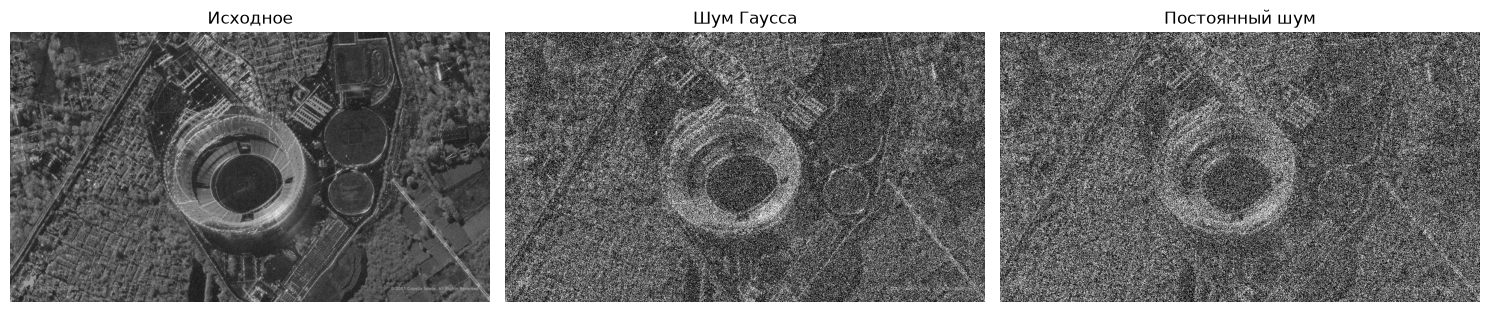

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import mean_squared_error, structural_similarity

np.random.seed(42)
image_gray = cv2.imread("sar_1.jpg", cv2.IMREAD_GRAYSCALE)

noise = np.random.normal(0, 100, image_gray.shape)
image_noise_gauss = np.clip(image_gray.astype(np.float32) + noise, 0, 255).astype(np.uint8)

noise = np.random.uniform(-200, 200, image_gray.shape)
image_noise_const = np.clip(image_gray.astype(np.float32) + noise, 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 4))
for i, (img, title) in enumerate([(image_gray, "Исходное"), (image_noise_gauss, "Шум Гаусса"), (image_noise_const, "Постоянный шум")]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap="gray"); plt.title(title); plt.axis("off")
plt.tight_layout(); plt.show()

# Task 2: Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.

# Медианный фильтр 

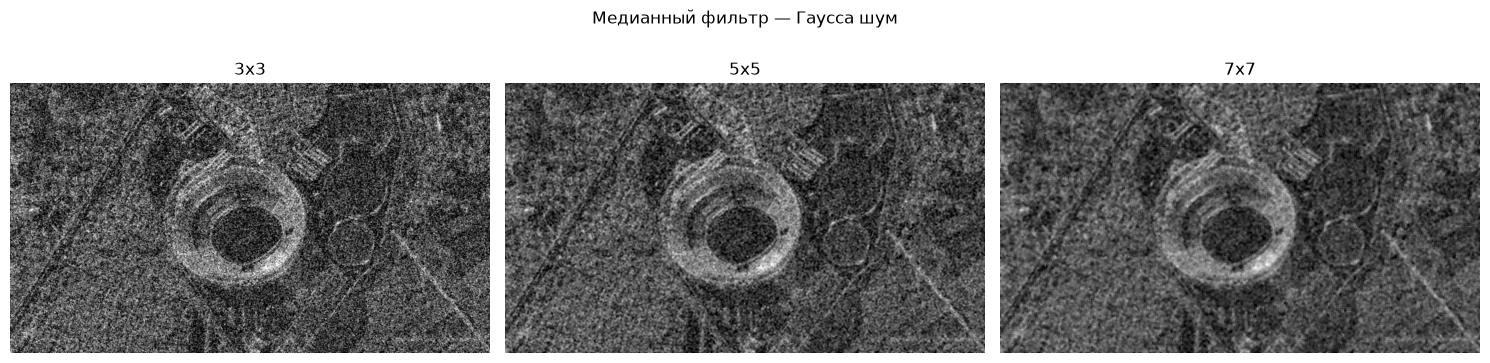

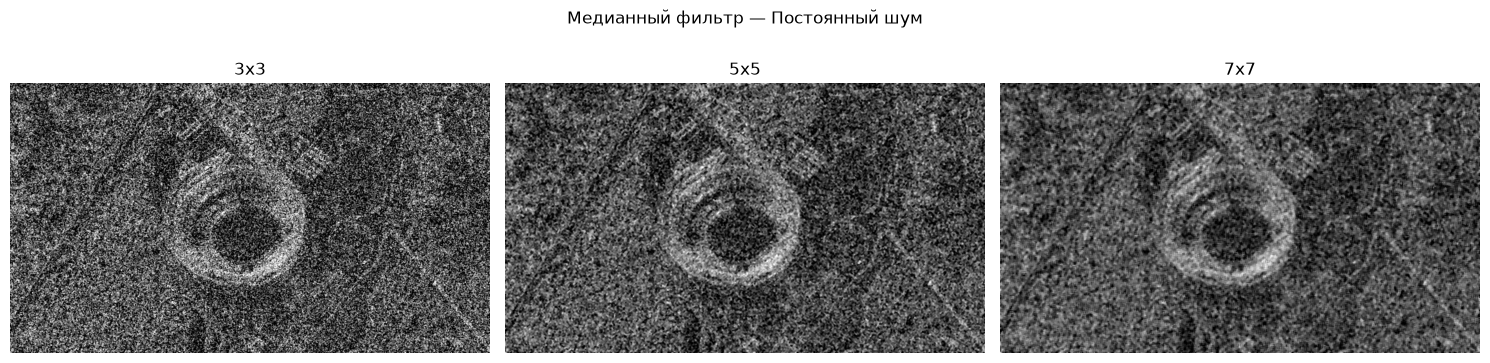

In [2]:
results = []

def add_result(noise_name, filter_name, param, filtered):
    mse = mean_squared_error(image_gray, filtered)
    ssim = structural_similarity(image_gray, filtered)
    results.append([noise_name, filter_name, param, mse, ssim])
    return mse, ssim

for noise_name, noisy in [("Гаусса", image_noise_gauss), ("Постоянный", image_noise_const)]:
    plt.figure(figsize=(15, 4))
    for i, k in enumerate([3, 5, 7], 1):
        filtered = cv2.medianBlur(noisy, k)
        mse, ssim = add_result(noise_name, "Медианный", f"kernel={k}", filtered)
        plt.subplot(1, 3, i); plt.imshow(filtered, cmap="gray")
        plt.title(f"{k}x{k}"); plt.axis("off")
    plt.suptitle(f"Медианный фильтр — {noise_name} шум"); plt.tight_layout(); plt.show()

# Фильтр Гаусса

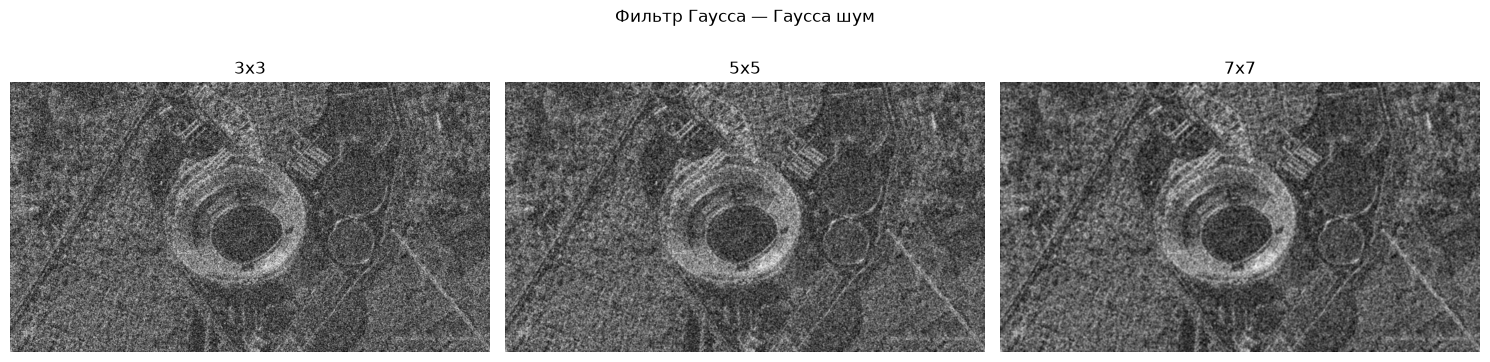

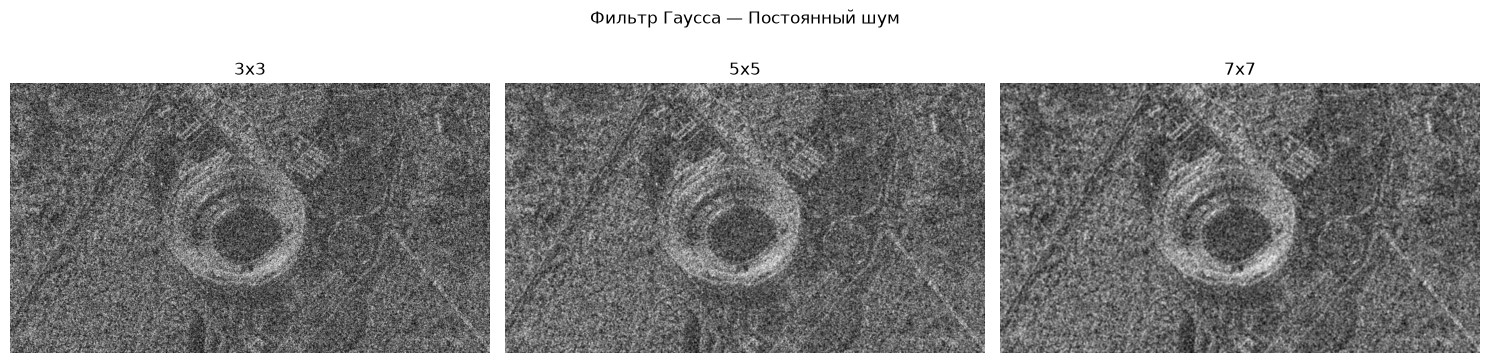

In [3]:
for noise_name, noisy in [("Гаусса", image_noise_gauss), ("Постоянный", image_noise_const)]:
    plt.figure(figsize=(15, 4))
    for i, k in enumerate([3, 5, 7], 1):
        filtered = cv2.GaussianBlur(noisy, (k, k), 0)
        mse, ssim = add_result(noise_name, "Гаусс", f"kernel={k}", filtered)
        plt.subplot(1, 3, i); plt.imshow(filtered, cmap="gray")
        plt.title(f"{k}x{k}"); plt.axis("off")
    plt.suptitle(f"Фильтр Гаусса — {noise_name} шум"); plt.tight_layout(); plt.show()

# Билатеральный фильтр

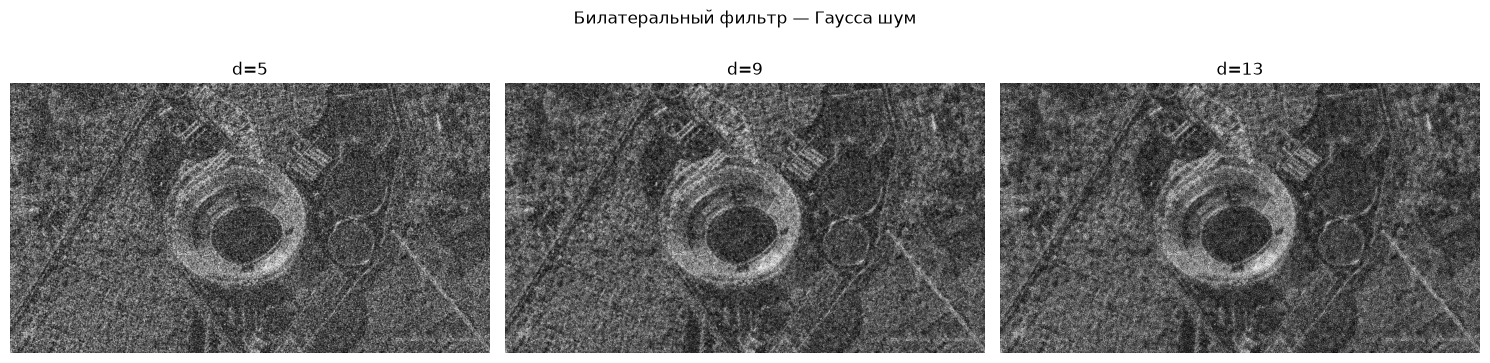

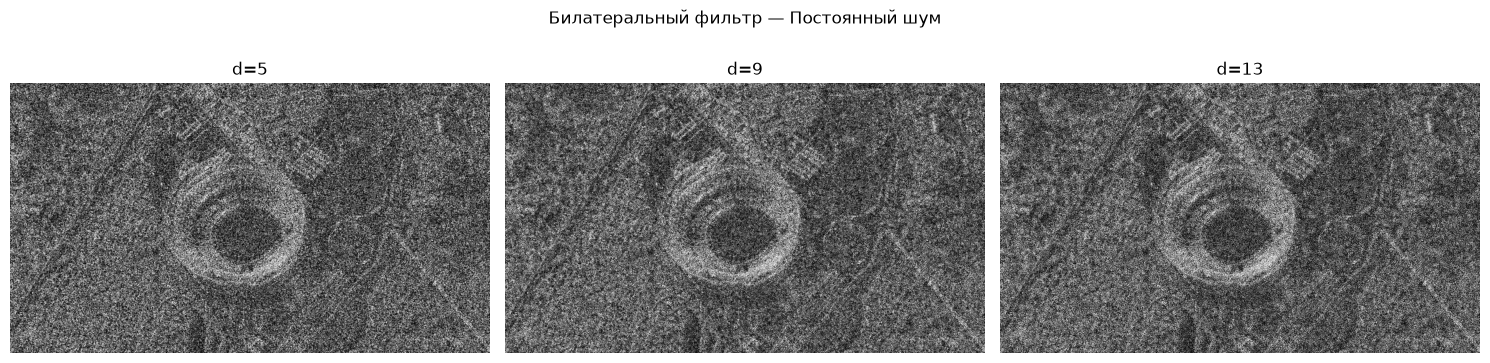

In [4]:
for noise_name, noisy in [("Гаусса", image_noise_gauss), ("Постоянный", image_noise_const)]:
    plt.figure(figsize=(15, 4))
    for i, d in enumerate([5, 9, 13], 1):
        filtered = cv2.bilateralFilter(noisy, d, 75, 75)
        mse, ssim = add_result(noise_name, "Билатеральный", f"d={d}", filtered)
        plt.subplot(1, 3, i); plt.imshow(filtered, cmap="gray")
        plt.title(f"d={d}"); plt.axis("off")
    plt.suptitle(f"Билатеральный фильтр — {noise_name} шум"); plt.tight_layout(); plt.show()

# Фильтр нелокальных средних

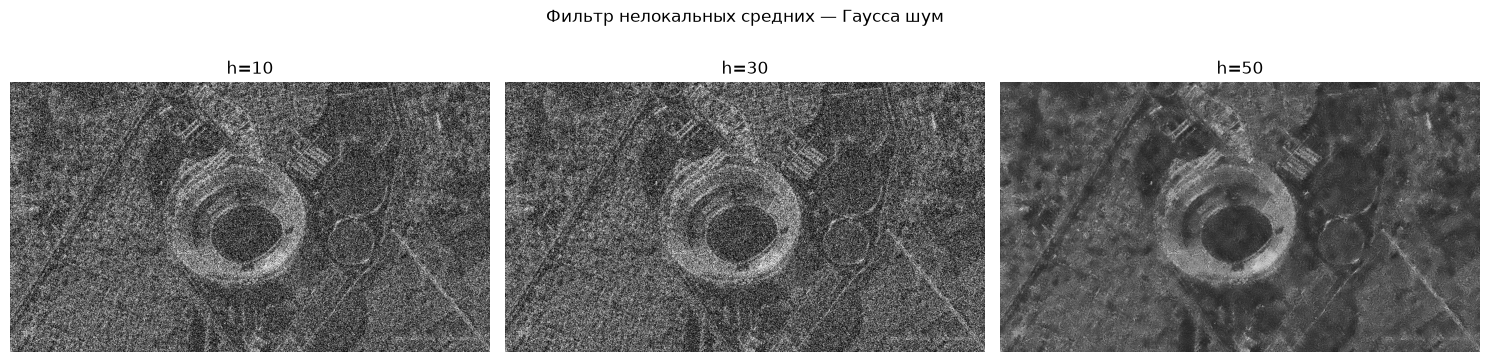

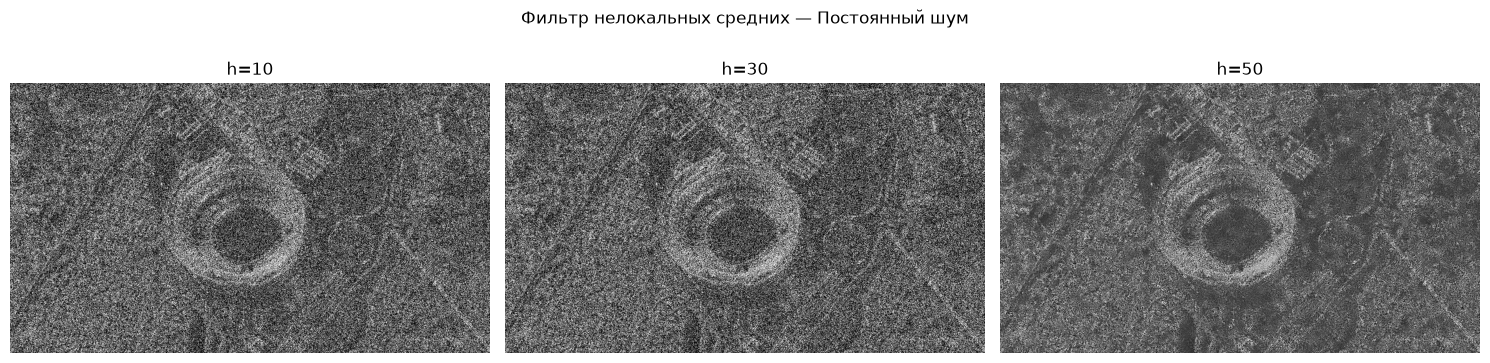

In [5]:
for noise_name, noisy in [("Гаусса", image_noise_gauss), ("Постоянный", image_noise_const)]:
    plt.figure(figsize=(15, 4))
    for i, h in enumerate([10, 30, 50], 1):
        filtered = cv2.fastNlMeansDenoising(noisy, None, h, 7, 21)
        mse, ssim = add_result(noise_name, "NLM", f"h={h}", filtered)
        plt.subplot(1, 3, i); plt.imshow(filtered, cmap="gray")
        plt.title(f"h={h}"); plt.axis("off")
    plt.suptitle(f"Фильтр нелокальных средних — {noise_name} шум"); plt.tight_layout(); plt.show()

# Task 3: Выяснить, какой фильтр показал лучший результат фильтрации шума.

In [6]:
print(f"{'Шум':<12} {'Фильтр':<18} {'Параметры':<14} {'MSE':>10} {'SSIM':>8}")
print("-" * 68)
for r in results:
    print(f"{r[0]:<12} {r[1]:<18} {r[2]:<14} {r[3]:>10.2f} {r[4]:>8.4f}")

for noise_name in ["Гаусса", "Постоянный"]:
    current = [r for r in results if r[0] == noise_name]
    best_mse = min(current, key=lambda x: x[3])
    best_ssim = max(current, key=lambda x: x[4])
    print(f"\n{noise_name} шум:")
    print(f"Лучший по MSE:  {best_mse[1]}, {best_mse[2]} (MSE={best_mse[3]:.2f})")
    print(f"Лучший по SSIM: {best_ssim[1]}, {best_ssim[2]} (SSIM={best_ssim[4]:.4f})")

Шум          Фильтр             Параметры             MSE     SSIM
--------------------------------------------------------------------
Гаусса       Медианный          kernel=3          1635.38   0.2140
Гаусса       Медианный          kernel=5           821.27   0.2803
Гаусса       Медианный          kernel=7           593.91   0.3061
Постоянный   Медианный          kernel=3          3100.93   0.1257
Постоянный   Медианный          kernel=5          1585.74   0.1766
Постоянный   Медианный          kernel=7          1039.40   0.2131
Гаусса       Гаусс              kernel=3          1096.80   0.2862
Гаусса       Гаусс              kernel=5           756.59   0.3516
Гаусса       Гаусс              kernel=7           605.73   0.3930
Постоянный   Гаусс              kernel=3          1640.97   0.2118
Постоянный   Гаусс              kernel=5          1159.63   0.2740
Постоянный   Гаусс              kernel=7           933.25   0.3221
Гаусса       Билатеральный      d=5               2889.53   